# ApexPlanet Task 4 - Advanced Analytics & Statistical Modeling

## Objective

The objective of this project is to apply statistical analysis, time-series analysis, customer segmentation, and basic predictive modeling to a retail sales dataset.

### Tasks Covered

1. Data Understanding and Preparation
2. Descriptive Statistical Analysis
3. Hypothesis Testing
   - Independent T-Test
   - Chi-Square Test
4. Confidence Intervals
5. Time Series Analysis
6. Trend, Seasonality and Residual Analysis
7. Moving Average Forecast
8. Customer Segmentation using K-Means
9. Elbow Method
10. PCA Visualization
11. Cluster Profiling
12. Predictive Modeling
13. Model Evaluation
14. Top 3 Important Features
15. Business Recommendations

In [59]:
import os
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from statsmodels.tsa.seasonal import seasonal_decompose

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

os.makedirs("../outputs", exist_ok=True)

In [60]:
DATA_PATH = "E:\\ApexPlanet-project\\Apex-planet-task4\\data\\cleaned_superstore_sales.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

display(df.head())

Dataset loaded successfully!
Rows: 10194
Columns: 21


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,State/Province,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,2023-01-03,2023-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,Texas,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,2023-01-05,2023-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,Pennsylvania,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


In [61]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
display(df.dtypes)

print("\nDataset Information:")
df.info()

Dataset Shape:
(10194, 21)

Column Names:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country/Region', 'City', 'State/Province', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

Data Types:


Row ID              int64
Order ID              str
Order Date            str
Ship Date             str
Ship Mode             str
Customer ID           str
Customer Name         str
Segment               str
Country/Region        str
City                  str
State/Province        str
Postal Code           str
Region                str
Product ID            str
Category              str
Sub-Category          str
Product Name          str
Sales             float64
Quantity            int64
Discount          float64
Profit            float64
dtype: object


Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  str    
 2   Order Date      10194 non-null  str    
 3   Ship Date       10194 non-null  str    
 4   Ship Mode       10194 non-null  str    
 5   Customer ID     10194 non-null  str    
 6   Customer Name   10194 non-null  str    
 7   Segment         10194 non-null  str    
 8   Country/Region  10194 non-null  str    
 9   City            10194 non-null  str    
 10  State/Province  10194 non-null  str    
 11  Postal Code     10194 non-null  str    
 12  Region          10194 non-null  str    
 13  Product ID      10194 non-null  str    
 14  Category        10194 non-null  str    
 15  Sub-Category    10194 non-null  str    
 16  Product Name    10194 non-null  str    
 17  Sales           1019

In [62]:
missing_data = pd.DataFrame({
    "Column": df.columns,
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": (
        df.isnull().sum() / len(df) * 100
    ).round(2)
})

display(
    missing_data.sort_values(
        "Missing Percentage",
        ascending=False
    )
)

,Column,Missing Values,Missing Percentage
Row ID,Row ID,0,0.0
Order ID,Order ID,0,0.0
Order Date,Order Date,0,0.0
Ship Date,Ship Date,0,0.0
Ship Mode,Ship Mode,0,0.0
Customer ID,Customer ID,0,0.0
Customer Name,Customer Name,0,0.0
Segment,Segment,0,0.0
Country/Region,Country/Region,0,0.0
City,City,0,0.0


In [63]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

if duplicate_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("Duplicate rows removed.")
else:
    print("No duplicate rows found.")

Duplicate rows: 0
No duplicate rows found.


In [64]:
df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    errors="coerce"
)

df["Ship Date"] = pd.to_datetime(
    df["Ship Date"],
    errors="coerce"
)

print(df[["Order Date", "Ship Date"]].dtypes)

Order Date    datetime64[us]
Ship Date     datetime64[us]
dtype: object


In [65]:
df["Shipping Days"] = (
    df["Ship Date"] - df["Order Date"]
).dt.days

display(
    df[
        [
            "Order Date",
            "Ship Date",
            "Shipping Days"
        ]
    ].head()
)

,Order Date,Ship Date,Shipping Days
0,2023-01-03,2023-01-07,4
1,2023-01-04,2023-01-08,4
2,2023-01-04,2023-01-08,4
3,2023-01-04,2023-01-08,4
4,2023-01-05,2023-01-12,7


In [66]:
numeric_cols = [
    "Sales",
    "Quantity",
    "Discount",
    "Profit",
    "Shipping Days"
]

print("Numeric columns:")
print(numeric_cols)

Numeric columns:
['Sales', 'Quantity', 'Discount', 'Profit', 'Shipping Days']


In [67]:
categorical_cols = [
    "Ship Mode",
    "Segment",
    "Country/Region",
    "City",
    "State/Province",
    "Region",
    "Category",
    "Sub-Category"
]

print("Categorical columns:")
print(categorical_cols)

Categorical columns:
['Ship Mode', 'Segment', 'Country/Region', 'City', 'State/Province', 'Region', 'Category', 'Sub-Category']


In [68]:
descriptive_stats = pd.DataFrame(index=numeric_cols)

descriptive_stats["Mean"] = df[numeric_cols].mean()

descriptive_stats["Median"] = df[numeric_cols].median()

descriptive_stats["Mode"] = (
    df[numeric_cols]
    .mode()
    .iloc[0]
)

descriptive_stats["Standard Deviation"] = (
    df[numeric_cols].std()
)

descriptive_stats["Variance"] = (
    df[numeric_cols].var()
)

descriptive_stats["Minimum"] = (
    df[numeric_cols].min()
)

descriptive_stats["Maximum"] = (
    df[numeric_cols].max()
)

descriptive_stats["Skewness"] = (
    df[numeric_cols].skew()
)

display(
    descriptive_stats.round(3)
)

,Mean,Median,Mode,Standard Deviation,Variance,Minimum,Maximum,Skewness
Sales,228.226,53.91,12.96,619.907,384284.489,0.444,22638.480,12.984
Quantity,3.792,3.00,2.00,2.228,4.965,1.000,14.000,1.269
Discount,0.155,0.20,0.00,0.206,0.043,0.000,0.800,1.687
Profit,28.673,8.69,0.00,232.465,54040.030,-6599.978,8399.976,7.605
Shipping Days,3.961,4.00,4.00,1.743,3.037,0.000,11.000,-0.412


In [69]:
descriptive_stats.to_csv(
    "../outputs/descriptive_statistics.csv"
)

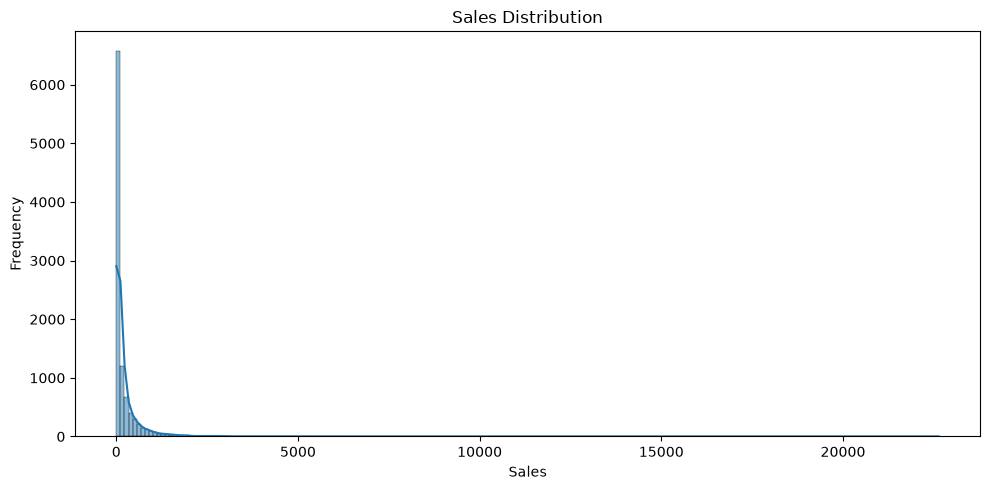

In [70]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["Sales"],
    kde=True
)

plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

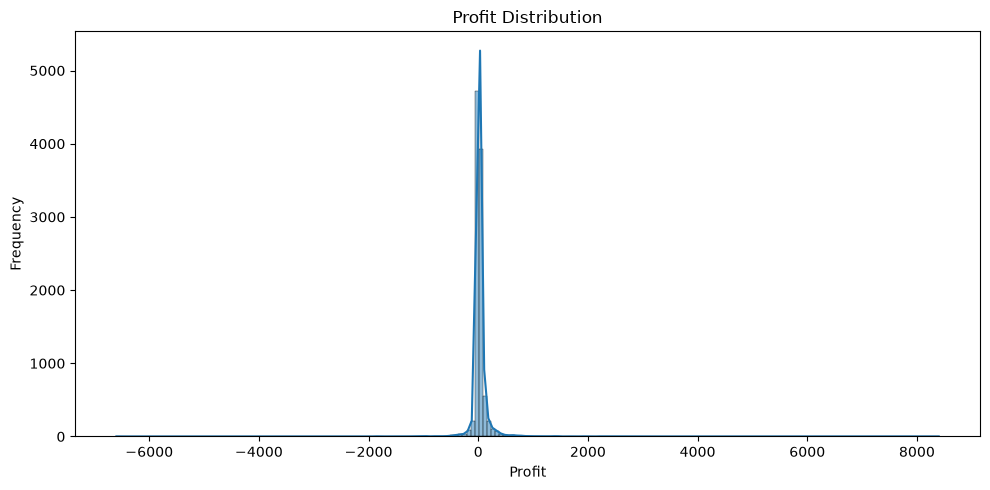

In [71]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["Profit"],
    kde=True
)

plt.title("Profit Distribution")
plt.xlabel("Profit")
plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

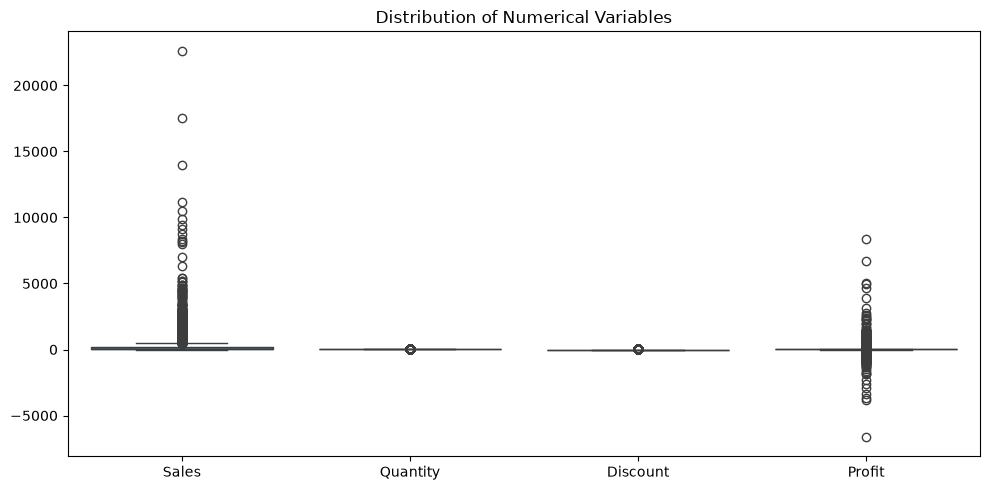

In [72]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df[
        ["Sales", "Quantity", "Discount", "Profit"]
    ]
)

plt.title("Distribution of Numerical Variables")

plt.tight_layout()

plt.show()

In [73]:
print(
    df["Segment"].value_counts()
)

Segment
Consumer       5281
Corporate      3090
Home Office    1823
Name: count, dtype: int64


In [74]:
consumer_profit = df[
    df["Segment"] == "Consumer"
]["Profit"].dropna()

corporate_profit = df[
    df["Segment"] == "Corporate"
]["Profit"].dropna()

t_stat, p_value = stats.ttest_ind(
    consumer_profit,
    corporate_profit,
    equal_var=False
)

print("Independent T-Test")
print("=" * 50)

print(
    "Consumer mean profit:",
    round(consumer_profit.mean(), 2)
)

print(
    "Corporate mean profit:",
    round(corporate_profit.mean(), 2)
)

print(
    "T-statistic:",
    round(t_stat, 4)
)

print(
    "P-value:",
    round(p_value, 6)
)

alpha = 0.05

if p_value < alpha:

    print("\nDecision: Reject H0")

    print(
        "There is a statistically significant "
        "difference in profit between Consumer "
        "and Corporate segments."
    )

else:

    print("\nDecision: Fail to reject H0")

    print(
        "There is no statistically significant "
        "difference in profit between Consumer "
        "and Corporate segments."
    )

Independent T-Test
Consumer mean profit: 25.82
Corporate mean profit: 30.5
T-statistic: -0.8814
P-value: 0.378147

Decision: Fail to reject H0
There is no statistically significant difference in profit between Consumer and Corporate segments.


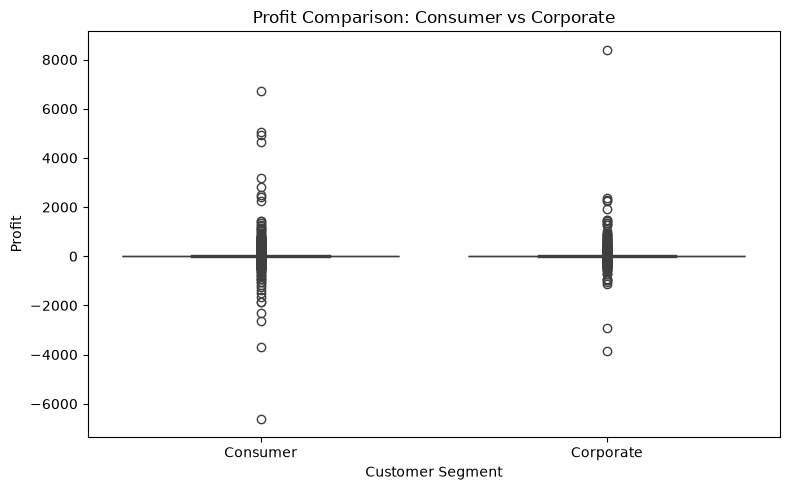

In [75]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df[
        df["Segment"].isin(
            ["Consumer", "Corporate"]
        )
    ],
    x="Segment",
    y="Profit"
)

plt.title(
    "Profit Comparison: Consumer vs Corporate"
)

plt.xlabel("Customer Segment")
plt.ylabel("Profit")

plt.tight_layout()

plt.show()

In [76]:
contingency_table = pd.crosstab(
    df["Category"],
    df["Region"]
)

print("Contingency Table:")

display(contingency_table)

Contingency Table:


Region,Central,East,South,West
Category,,,,
Furniture,485,649,332,735
Office Supplies,1430,1792,995,1911
Technology,420,545,293,607


In [77]:
chi2, p_value, dof, expected = stats.chi2_contingency(
    contingency_table
)

print("Chi-Square Test")
print("=" * 50)

print(
    "Chi-square statistic:",
    round(chi2, 4)
)

print(
    "Degrees of freedom:",
    dof
)

print(
    "P-value:",
    round(p_value, 6)
)

alpha = 0.05

if p_value < alpha:

    print("\nDecision: Reject H0")

    print(
        "There is a statistically significant "
        "association between Category and Region."
    )

else:

    print("\nDecision: Fail to reject H0")

    print(
        "There is no statistically significant "
        "association between Category and Region."
    )

Chi-Square Test
Chi-square statistic: 5.5472
Degrees of freedom: 6
P-value: 0.475766

Decision: Fail to reject H0
There is no statistically significant association between Category and Region.


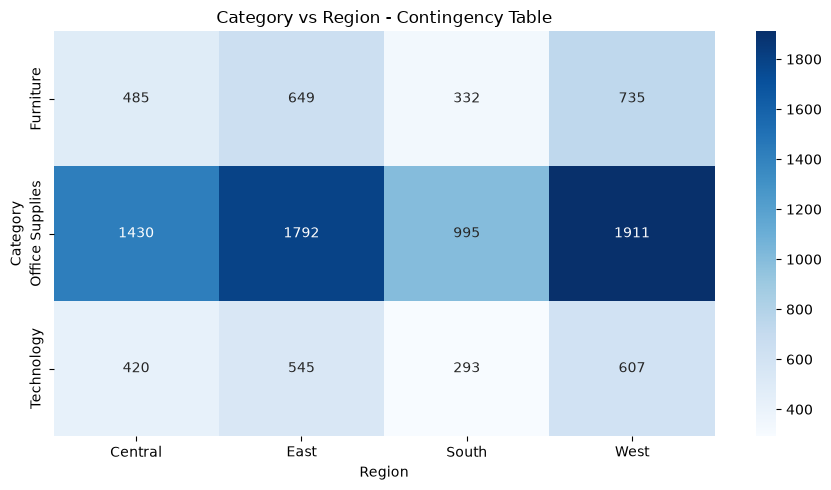

In [78]:
plt.figure(figsize=(9, 5))

sns.heatmap(
    contingency_table,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "Category vs Region - Contingency Table"
)

plt.xlabel("Region")
plt.ylabel("Category")

plt.tight_layout()

plt.show()

In [79]:
confidence_results = []

for column in [
    "Sales",
    "Profit",
    "Quantity"
]:

    values = df[column].dropna()

    mean = values.mean()

    standard_error = stats.sem(values)

    lower, upper = stats.t.interval(
        confidence=0.95,
        df=len(values) - 1,
        loc=mean,
        scale=standard_error
    )

    confidence_results.append({
        "Variable": column,
        "Mean": mean,
        "Lower 95% CI": lower,
        "Upper 95% CI": upper
    })

confidence_df = pd.DataFrame(
    confidence_results
)

display(
    confidence_df.round(3)
)

,Variable,Mean,Lower 95% CI,Upper 95% CI
0,Sales,228.226,216.191,240.261
1,Profit,28.673,24.160,33.187
2,Quantity,3.792,3.749,3.835


In [80]:
confidence_df.to_csv(
    "../outputs/confidence_intervals.csv",
    index=False
)

### TIME SERIES ANALYSIS

In [81]:
monthly_sales = (
    df
    .set_index("Order Date")
    .resample("ME")["Sales"]
    .sum()
)

display(
    monthly_sales.head(12)
)

Order Date
2023-01-31    14518.0550
2023-02-28     4519.8920
2023-03-31    56933.9090
2023-04-30    28295.3450
2023-05-31    26319.7670
2023-06-30    34669.4796
2023-07-31    33946.3930
2023-08-31    28918.3385
2023-09-30    82670.4288
2023-10-31    32413.3390
2023-11-30    78826.9567
2023-12-31    72008.3085
Freq: ME, Name: Sales, dtype: float64

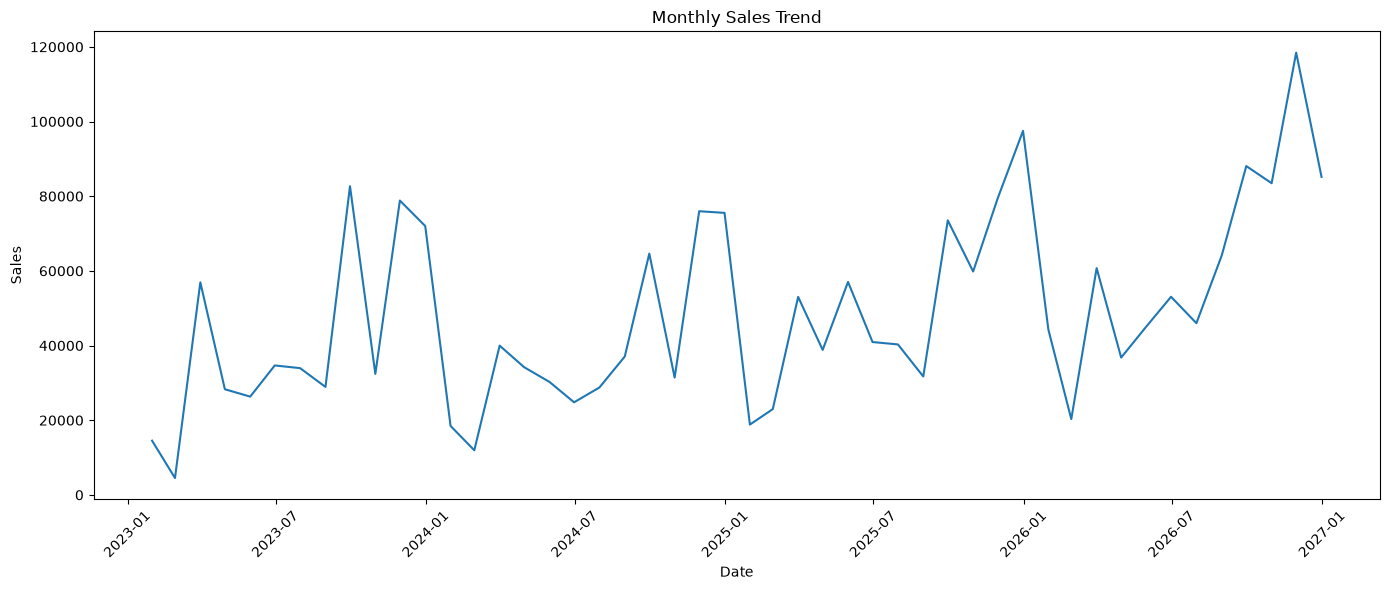

In [82]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values
)

plt.title(
    "Monthly Sales Trend"
)

plt.xlabel("Date")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../outputs/monthly_sales.png",
    dpi=300
)

plt.show()

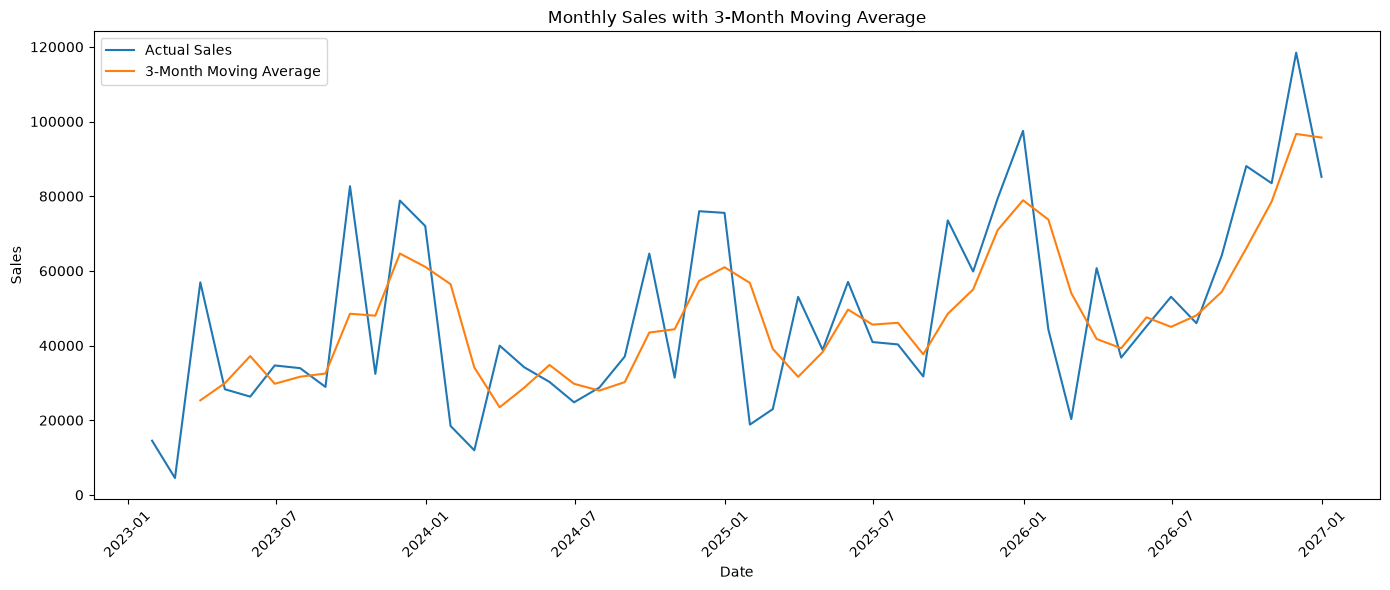

In [83]:
moving_average = monthly_sales.rolling(
    window=3
).mean()

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    label="Actual Sales"
)

plt.plot(
    moving_average.index,
    moving_average.values,
    label="3-Month Moving Average"
)

plt.title(
    "Monthly Sales with 3-Month Moving Average"
)

plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../outputs/moving_average_forecast.png",
    dpi=300
)

plt.show()

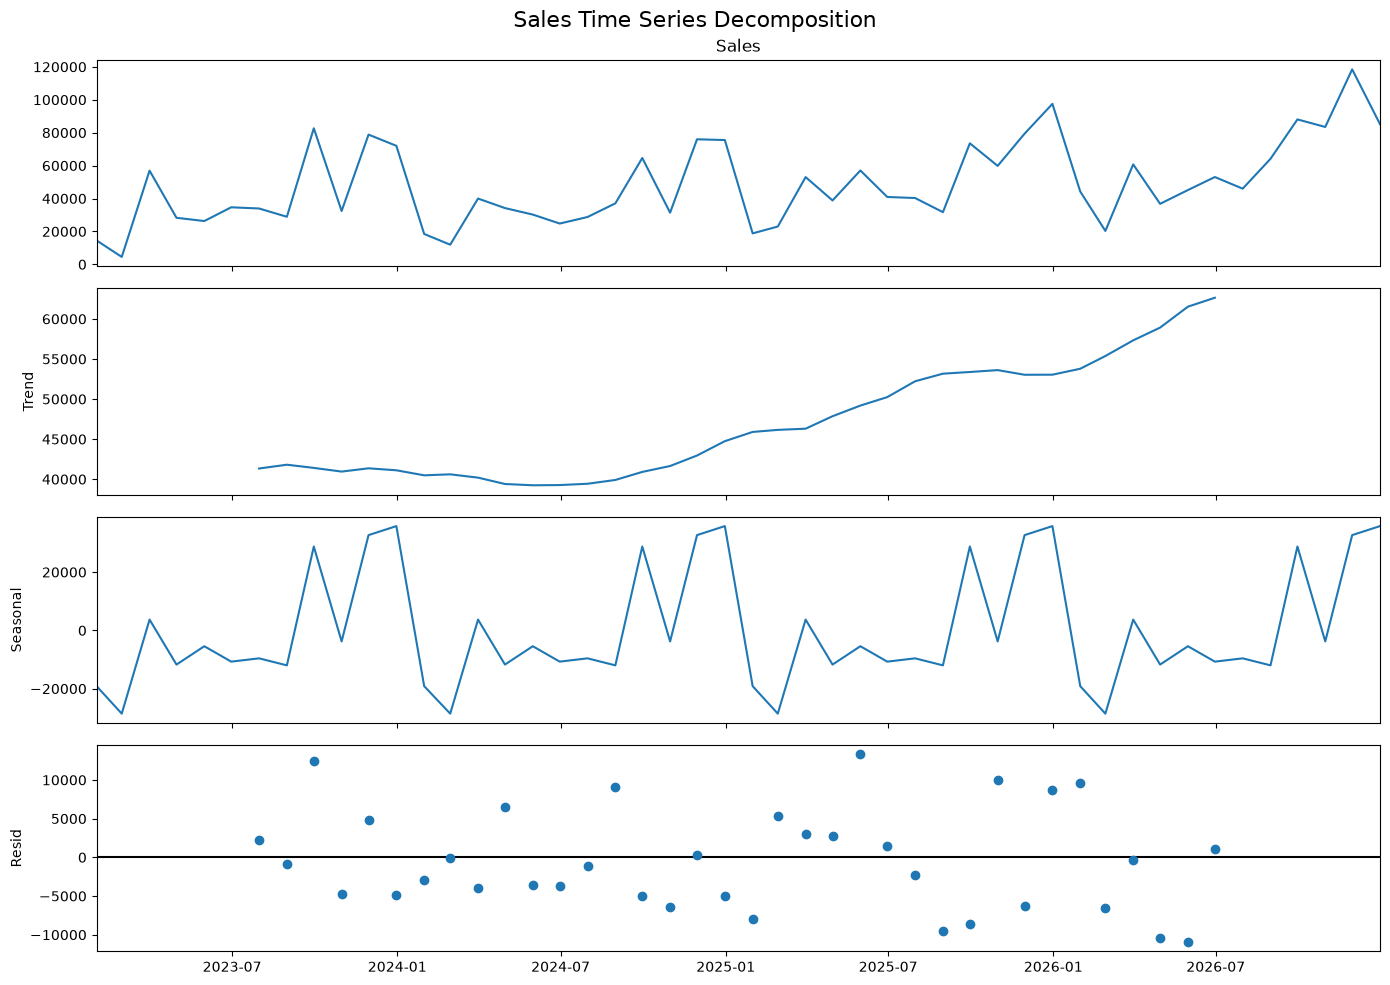

In [84]:
decomposition = seasonal_decompose(
    monthly_sales,
    model="additive",
    period=12
)

# Create the figure first
fig = decomposition.plot()

# Set figure size
fig.set_size_inches(14, 10)

# Add title
fig.suptitle(
    "Sales Time Series Decomposition",
    fontsize=16
)

# Adjust layout
plt.tight_layout()

# Leave space for the title
fig.subplots_adjust(top=0.93)

# Save the figure
plt.savefig(
    "../outputs/time_series_decomposition.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### CUSTOMER SEGMENTATION

In [85]:
customer_data = df.groupby(
    "Customer ID"
).agg({

    "Sales": "sum",

    "Quantity": "sum",

    "Discount": "mean",

    "Profit": "sum",

    "Order ID": "nunique"

}).reset_index()

customer_data = customer_data.rename(
    columns={
        "Order ID": "Number of Orders"
    }
)

display(
    customer_data.head()
)

,Customer ID,Sales,Quantity,Discount,Profit,Number of Orders
0,AA-10315,5563.560,30,0.090909,-362.8825,5
1,AA-10375,1056.390,41,0.080000,277.3824,9
2,AA-10480,1790.512,36,0.016667,435.8274,4
3,AA-10645,5086.935,64,0.063889,857.8033,6
4,AB-10015,886.156,13,0.066667,129.3465,3


In [86]:
print(
    "Number of customers:",
    len(customer_data)
)

print(
    "\nCustomer segmentation features:"
)

print(
    customer_data.columns.tolist()
)

Number of customers: 804

Customer segmentation features:
['Customer ID', 'Sales', 'Quantity', 'Discount', 'Profit', 'Number of Orders']


In [87]:
cluster_features = [
    "Sales",
    "Quantity",
    "Discount",
    "Profit",
    "Number of Orders"
]

X_cluster = customer_data[
    cluster_features
].copy()

X_cluster = X_cluster.fillna(
    X_cluster.median()
)

print(
    X_cluster.describe()
)

              Sales    Quantity    Discount       Profit  Number of Orders
count    804.000000  804.000000  804.000000   804.000000        804.000000
mean    2893.699446   48.077114    0.157705   363.553252          6.364428
std     2653.778471   26.106192    0.092412   893.034012          2.660121
min        4.833000    2.000000    0.000000 -6626.389500          1.000000
25%     1084.538000   30.000000    0.089023    35.379225          5.000000
50%     2243.392000   44.000000    0.150000   226.945650          6.000000
75%     3790.812100   63.000000    0.211111   564.085725          8.000000
max    25043.050000  154.000000    0.700000  8981.323900         17.000000


In [88]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    X_cluster
)

print(
    "Scaled data shape:",
    X_scaled.shape
)

Scaled data shape: (804, 5)


In [89]:
inertia = []

k_values = range(2, 11)

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(
        kmeans.inertia_
    )

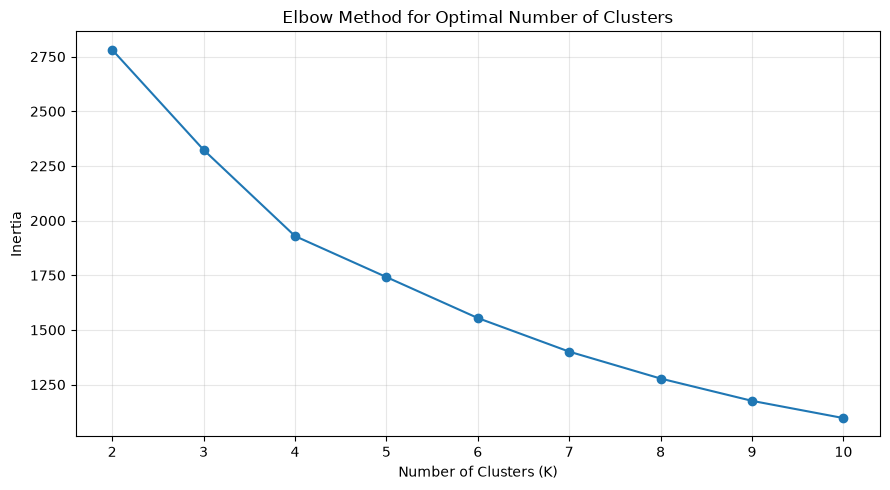

In [90]:
plt.figure(figsize=(9, 5))

plt.plot(
    list(k_values),
    inertia,
    marker="o"
)

plt.title(
    "Elbow Method for Optimal Number of Clusters"
)

plt.xlabel(
    "Number of Clusters (K)"
)

plt.ylabel(
    "Inertia"
)

plt.xticks(
    list(k_values)
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../outputs/elbow_method.png",
    dpi=300
)

plt.show()

In [91]:
OPTIMAL_K = 4

print(
    "Selected number of clusters:",
    OPTIMAL_K
)

Selected number of clusters: 4


In [92]:
kmeans = KMeans(
    n_clusters=OPTIMAL_K,
    random_state=42,
    n_init=10
)

customer_data["Cluster"] = kmeans.fit_predict(
    X_scaled
)

print("Customer clustering completed!")

display(
    customer_data.head()
)

Customer clustering completed!


,Customer ID,Sales,Quantity,Discount,Profit,Number of Orders,Cluster
0,AA-10315,5563.560,30,0.090909,-362.8825,5,3
1,AA-10375,1056.390,41,0.080000,277.3824,9,3
2,AA-10480,1790.512,36,0.016667,435.8274,4,3
3,AA-10645,5086.935,64,0.063889,857.8033,6,1
4,AB-10015,886.156,13,0.066667,129.3465,3,3


In [93]:
cluster_counts = (
    customer_data["Cluster"]
    .value_counts()
    .sort_index()
)

display(cluster_counts)

Cluster
0    202
1    264
2     55
3    283
Name: count, dtype: int64

In [94]:
pca = PCA(
    n_components=2
)

X_pca = pca.fit_transform(
    X_scaled
)

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df["Cluster"] = (
    customer_data["Cluster"].values
)

print(
    "PC1 variance:",
    round(
        pca.explained_variance_ratio_[0] * 100,
        2
    ),
    "%"
)

print(
    "PC2 variance:",
    round(
        pca.explained_variance_ratio_[1] * 100,
        2
    ),
    "%"
)

print(
    "Total variance explained:",
    round(
        pca.explained_variance_ratio_.sum() * 100,
        2
    ),
    "%"
)

PC1 variance: 48.68 %
PC2 variance: 24.68 %
Total variance explained: 73.36 %


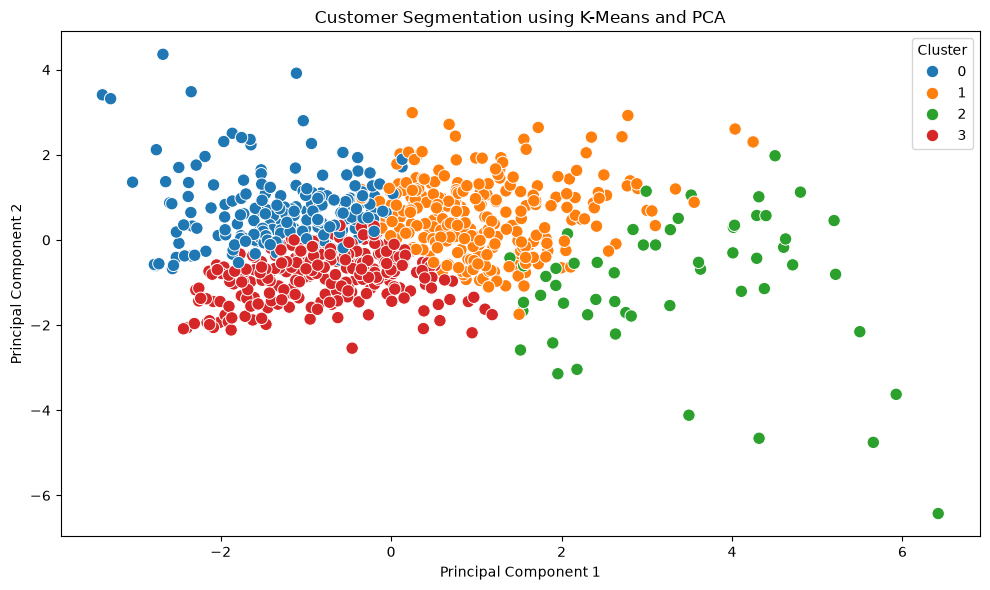

In [95]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="tab10",
    s=80
)

plt.title(
    "Customer Segmentation using K-Means and PCA"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.legend(
    title="Cluster"
)

plt.tight_layout()

plt.savefig(
    "../outputs/customer_segments_pca.png",
    dpi=300
)

plt.show()

In [96]:
cluster_profile = customer_data.groupby(
    "Cluster"
)[cluster_features].mean()

display(
    cluster_profile.round(2)
)

,Sales,Quantity,Discount,Profit,Number of Orders
Cluster,,,,,
0,1551.19,32.09,0.26,-96.28,4.69
1,3712.55,69.67,0.16,367.00,8.81
2,9717.80,81.24,0.12,2281.43,8.62
3,1761.84,32.89,0.09,315.83,4.84


In [97]:
cluster_profile.to_csv(
    "../outputs/cluster_profile.csv"
)

In [98]:
cluster_profile_full = customer_data.groupby(
    "Cluster"
).agg({

    "Sales": "mean",

    "Quantity": "mean",

    "Discount": "mean",

    "Profit": "mean",

    "Number of Orders": "mean",

    "Customer ID": "count"

}).rename(
    columns={
        "Customer ID": "Customer Count"
    }
)

display(
    cluster_profile_full.round(2)
)

,Sales,Quantity,Discount,Profit,Number of Orders,Customer Count
Cluster,,,,,,
0,1551.19,32.09,0.26,-96.28,4.69,202
1,3712.55,69.67,0.16,367.00,8.81,264
2,9717.80,81.24,0.12,2281.43,8.62,55
3,1761.84,32.89,0.09,315.83,4.84,283


In [99]:
customer_data.to_csv(
    "../outputs/customer_segments.csv",
    index=False
)

### PREDICTIVE MODELING

In [100]:
model_features = [
    "Sales",
    "Quantity",
    "Discount",
    "Shipping Days",
    "Ship Mode",
    "Segment",
    "Region",
    "Category",
    "Sub-Category"
]

TARGET = "Profit"

X = df[model_features].copy()

y = df[TARGET].copy()

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(TARGET)

Features:
['Sales', 'Quantity', 'Discount', 'Shipping Days', 'Ship Mode', 'Segment', 'Region', 'Category', 'Sub-Category']

Target:
Profit


In [101]:
numeric_features = [
    "Sales",
    "Quantity",
    "Discount",
    "Shipping Days"
]

categorical_features = [
    "Ship Mode",
    "Segment",
    "Region",
    "Category",
    "Sub-Category"
]

In [102]:
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),

        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),

        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),

        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

In [103]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(
    "Training samples:",
    len(X_train)
)

print(
    "Testing samples:",
    len(X_test)
)

print(
    "\nTraining percentage:",
    round(len(X_train) / len(X) * 100, 2),
    "%"
)

print(
    "Testing percentage:",
    round(len(X_test) / len(X) * 100, 2),
    "%"
)

Training samples: 8155
Testing samples: 2039

Training percentage: 80.0 %
Testing percentage: 20.0 %


In [104]:
model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),

        (
            "regressor",
            LinearRegression()
        )
    ]
)

model.fit(
    X_train,
    y_train
)

print(
    "Linear Regression model trained successfully."
)

Linear Regression model trained successfully.


In [105]:
y_pred = model.predict(
    X_test
)

prediction_df = pd.DataFrame({

    "Actual Profit": y_test.values,

    "Predicted Profit": y_pred

})

display(
    prediction_df.head(10)
)

,Actual Profit,Predicted Profit
0,-14.3313,-98.610330
1,4.7712,-14.540164
2,-7.7094,18.857005
3,108.1752,102.877263
4,218.2518,170.991148
5,585.5520,289.904214
6,48.9645,43.647148
7,20.6820,62.366910
8,1.7876,27.520035
9,28.0032,117.894438


In [106]:
r2 = r2_score(
    y_test,
    y_pred
)

mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

print("Model Evaluation")
print("=" * 50)

print(
    "R² Score:",
    round(r2, 4)
)

print(
    "MAE:",
    round(mae, 4)
)

print(
    "RMSE:",
    round(rmse, 4)
)

Model Evaluation
R² Score: 0.4893
MAE: 61.6808
RMSE: 214.0702


In [107]:
model_metrics = pd.DataFrame({

    "Metric": [
        "R2",
        "MAE",
        "RMSE"
    ],

    "Value": [
        r2,
        mae,
        rmse
    ]
})

display(
    model_metrics.round(4)
)

model_metrics.to_csv(
    "../outputs/model_metrics.csv",
    index=False
)

,Metric,Value
0,R2,0.4893
1,MAE,61.6808
2,RMSE,214.0702


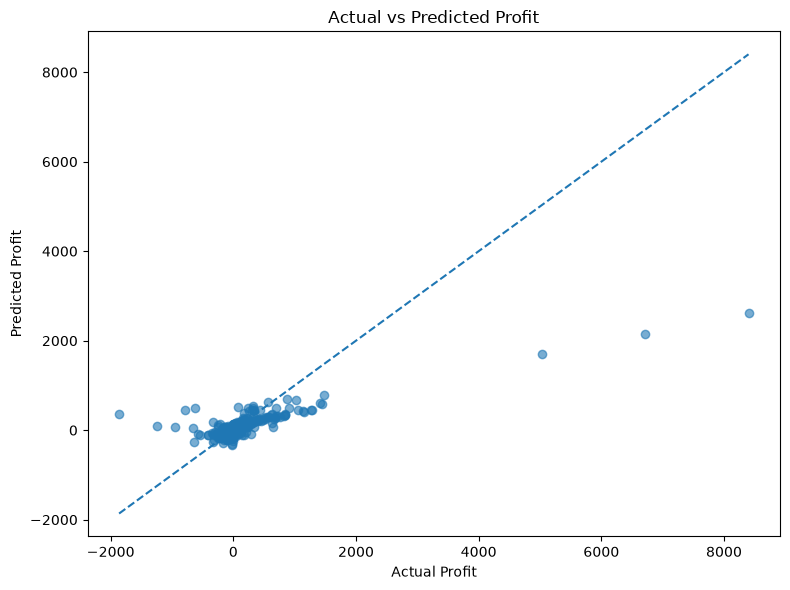

In [108]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6
)

min_value = min(
    y_test.min(),
    y_pred.min()
)

max_value = max(
    y_test.max(),
    y_pred.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel(
    "Actual Profit"
)

plt.ylabel(
    "Predicted Profit"
)

plt.title(
    "Actual vs Predicted Profit"
)

plt.tight_layout()

plt.savefig(
    "../outputs/actual_vs_predicted.png",
    dpi=300
)

plt.show()

In [109]:
feature_names = (
    model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

coefficients = (
    model
    .named_steps["regressor"]
    .coef_
)

feature_importance = pd.DataFrame({

    "Feature": feature_names,

    "Coefficient": coefficients,

    "Absolute Importance": np.abs(
        coefficients
    )

})

feature_importance = (
    feature_importance
    .sort_values(
        "Absolute Importance",
        ascending=False
    )
)

display(
    feature_importance.head(10)
)

,Feature,Coefficient,Absolute Importance
24,cat__Sub-Category_Copiers,296.322334,296.322334
29,cat__Sub-Category_Machines,-188.776076,188.776076
0,num__Sales,75.000666,75.000666
21,cat__Sub-Category_Binders,71.225489,71.225489
34,cat__Sub-Category_Tables,-62.613905,62.613905
2,num__Discount,-62.350756,62.350756
33,cat__Sub-Category_Supplies,-47.158233,47.158233
17,cat__Category_Technology,40.380579,40.380579
15,cat__Category_Furniture,-35.353095,35.353095
27,cat__Sub-Category_Furnishings,33.955174,33.955174


In [110]:
top_3_features = (
    feature_importance
    .head(3)
)

print("Top 3 Important Features:")

display(
    top_3_features
)

Top 3 Important Features:


,Feature,Coefficient,Absolute Importance
24,cat__Sub-Category_Copiers,296.322334,296.322334
29,cat__Sub-Category_Machines,-188.776076,188.776076
0,num__Sales,75.000666,75.000666


In [111]:
top_3_features.to_csv(
    "../outputs/feature_importance.csv",
    index=False
)

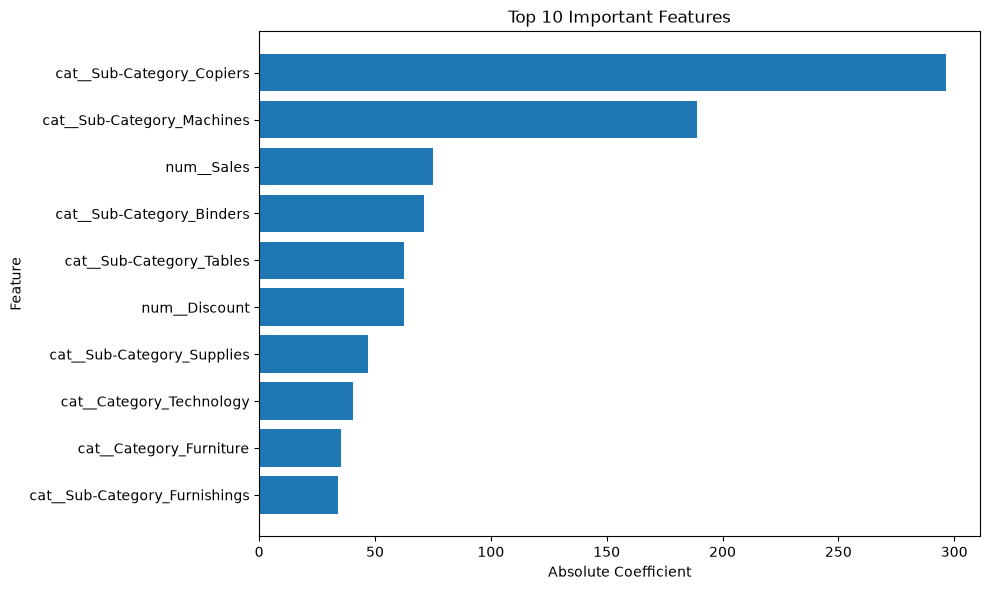

In [112]:
top_10 = (
    feature_importance
    .head(10)
    .sort_values(
        "Absolute Importance"
    )
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_10["Feature"],
    top_10["Absolute Importance"]
)

plt.title(
    "Top 10 Important Features"
)

plt.xlabel(
    "Absolute Coefficient"
)

plt.ylabel(
    "Feature"
)

plt.tight_layout()

plt.savefig(
    "../outputs/feature_importance.png",
    dpi=300
)

plt.show()

# Final Business Insights

## 1. Statistical Analysis

Descriptive statistics were used to understand the distribution, central tendency, and variability of sales, quantity, discount, profit, and shipping time.

Mean, median, mode, standard deviation, variance, and skewness were calculated.

## 2. Hypothesis Testing

An independent t-test was conducted to compare the profit of Consumer and Corporate customer segments.

The p-value was compared with a significance level of 0.05 to determine whether the difference between the two groups was statistically significant.

A chi-square test was conducted to examine the relationship between product Category and Region.

## 3. Confidence Intervals

95% confidence intervals were calculated for Sales, Profit, and Quantity to estimate the range within which the population mean is expected to fall.

## 4. Time Series Analysis

Order Date was converted into a datetime format and sales were aggregated monthly.

Monthly sales trends were visualized using line plots.

A 3-month moving average was calculated to smooth short-term fluctuations.

Time-series decomposition was also performed to analyze:

- Trend
- Seasonality
- Residuals

## 5. Customer Segmentation

Customers were grouped based on:

- Total Sales
- Total Quantity
- Average Discount
- Total Profit
- Number of Orders

The features were standardized using StandardScaler.

K-Means clustering was applied and the elbow method was used to determine a suitable number of clusters.

PCA was used to visualize customer segments in two dimensions.

## 6. Predictive Modeling

A Linear Regression model was developed to predict Profit.

The dataset was divided into 80% training data and 20% testing data.

The model was evaluated using:

- R²
- MAE
- RMSE

The three most important predictive features were identified based on the absolute magnitude of the model coefficients.

## 7. Business Recommendations

The customer segmentation can help identify high-value, low-value, and opportunity customers.

High-value customers can be targeted with loyalty programs and personalized offers.

Customers receiving high discounts but generating low profit should be analyzed to improve discount strategies.

Sales trends and seasonality can help businesses plan inventory and marketing campaigns.

The predictive model can provide insights into the variables associated with profitability and support data-driven business decisions.